<a href="https://colab.research.google.com/github/jonahduffy/Movie-Data-Machine-Learning-Pipeline/blob/main/movie_data_ml_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Critic Scores vs. Audience Reception: A Data & NLP Pipeline
**Author:** Jonah Duffy  

**Project Overview:** This notebook extracts semi-structured movie data from a NoSQL MongoDB database to analyze the relationship between professional critic scores (Metacritic) and general audience reception (IMDB). It utilizes an Ordinary Least Squares (OLS) regression for statistical modeling, followed by a Hugging Face Natural Language Processing (NLP) transformer to classify the emotional sentiment of the movie descriptions.

In [1]:
# Install required packages for MongoDB connection and Hugging Face NLP
%pip install -q "pymongo[srv]"
%pip install -q transformers

# Disable interactive progress bars to prevent GitHub rendering errors
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 42.1 MB/s eta 0:00:00


### Phase 1: Data Extraction & Preprocessing
Connecting securely to the MongoDB Atlas cluster to extract the `imdb` and `metacritic` collections for the year 2015, cleaning the internal IDs, and performing an inner merge to create a unified dataset.

In [2]:
import pandas as pd
import pymongo
import certifi
from google.colab import userdata

# 1. Connect securely to your cluster
mongo_uri = userdata.get('mongodb')
client = pymongo.MongoClient(mongo_uri, tlsCAFile=certifi.where())
db = client['MovieData']

target_year = "2015"
print(f"Fetching data for the year {target_year} using 'release_date'...")

# 2. Query MongoDB using a regex matching any date starting with or containing the year
year_regex = {"$regex": str(target_year)}

imdb_cursor = db.imdb.find({"release_date": year_regex})
meta_cursor = db.Metacritic.find({"release_date": year_regex})

# 3. Convert to Pandas DataFrames
df_imdb = pd.DataFrame(list(imdb_cursor))
df_metacritic = pd.DataFrame(list(meta_cursor))

# 4. Verify if any records were found before attempting a merge
if df_imdb.empty or df_metacritic.empty:
    print(f"\nWarning: One of your collections returned 0 records for the year {target_year}.")
    print(f"IMDB records found: {df_imdb.shape[0]}")
    print(f"Metacritic records found: {df_metacritic.shape[0]}")
    print("\nIf both are 0, 'release_date' might be a Date object. Let us know and we can switch to a range query!")
else:
    # 5. Clean up the MongoDB internal '_id' column
    if '_id' in df_imdb.columns:
        df_imdb = df_imdb.drop(columns=['_id'])
    if '_id' in df_metacritic.columns:
        df_metacritic = df_metacritic.drop(columns=['_id'])

    # 6. Perform the inner merge on matching movie titles
    merged_df = pd.merge(df_imdb, df_metacritic, how="inner", on="title")

    print("\n--- Data Pipeline Summary ---")
    print(f"IMDB documents fetched: {df_imdb.shape[0]}")
    print(f"Metacritic documents fetched: {df_metacritic.shape[0]}")
    print(f"Successfully merged rows: {merged_df.shape[0]}")

    if not merged_df.empty:
        print("\nColumns available in your final merged DataFrame:")
        print(list(merged_df.columns))

Fetching data for the year 2015 using 'release_date'...

--- Data Pipeline Summary ---
IMDB documents fetched: 1335
Metacritic documents fetched: 640
Successfully merged rows: 286

Columns available in your final merged DataFrame:
['id', 'title', 'runtime', 'user_rating', 'votes', 'mpaa_rating', 'release_date_x', 'budget', 'opening_weekend', 'gross_sales', 'genres', 'cast', 'director', 'producer', 'company', 'movie_id', 'release_date_y', 'description', 'score', 'thumbnail']


### Phase 2: Statistical Modeling (OLS Regression)
Using `statsmodels` to quantify exactly how much of the variance in IMDB user ratings can be predicted by the Metacritic critic score.

In [3]:
import statsmodels.formula.api as smf

# 1. Fit the Ordinary Least Squares (OLS) regression model
model = smf.ols(formula='user_rating ~ score', data=merged_df).fit()

# 2. Print the complete statistical summary table
print("==============================================================================")
print("                        OLS REGRESSION ANALYSIS RESULTS                       ")
print("==============================================================================")
print(model.summary())

                        OLS REGRESSION ANALYSIS RESULTS                       
                            OLS Regression Results                            
Dep. Variable:            user_rating   R-squared:                       0.528
Model:                            OLS   Adj. R-squared:                  0.527
Method:                 Least Squares   F-statistic:                     318.1
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           2.93e-48
Time:                        03:41:06   Log-Likelihood:                -290.56
No. Observations:                 286   AIC:                             585.1
Df Residuals:                     284   BIC:                             592.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

### Phase 3: AI Sentiment Analysis Pipeline
Deploying a pre-trained Hugging Face NLP model (`twitter-xlm-roberta-base-sentiment`) to read the plot description of every movie and classify its tone.

In [4]:
from transformers import pipeline

print("Downloading the AI/ML model... (This may take a minute or two)")

# Initialize the specific sentiment pipeline requested
sentiment_model = pipeline(model="cardiffnlp/twitter-xlm-roberta-base-sentiment")

# Define a helper function to safely process the text
def analyze_sentiment(text):
    try:
        safe_text = str(text)[:500]
        result = sentiment_model(safe_text)
        return result[0]['label']
    except Exception as e:
        return "neutral" # Default fallback in case of missing text

print(f"Analyzing sentiment for all {merged_df.shape[0]} movies... please wait.")

# Apply the AI model to create new analysis column
merged_df['sentiment_analysis'] = merged_df['description'].apply(analyze_sentiment)

print("AI/ML Pipeline Complete! \n")

# Display the results
print(merged_df[['title', 'sentiment_analysis', 'description']].head(5))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Analyzing sentiment for all 286 movies... please wait.
AI/ML Pipeline Complete! 

                    title sentiment_analysis  \
0             The Martian           negative   
1      Mad Max: Fury Road           negative   
2  Straight Outta Compton           negative   
3        Hitman: Agent 47           negative   
4               Furious 7           negative   

                                         description  
0  During a manned mission to Mars, Astronaut Mar...  
1  In the furthest reaches of our planet, in a st...  
2  In the mid-1980s, the streets of Compton, Cali...  
3  Agent 47 is an elite assassin, genetically eng...  
4  After Dominic Toretto and his crew helped take...  


### Phase 4: Data Visualization
Generating side-by-side comparative charts using `seaborn` to visualize both the statistical trendline and the AI sentiment distribution.

/tmp/ipykernel_5898/1470998007.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


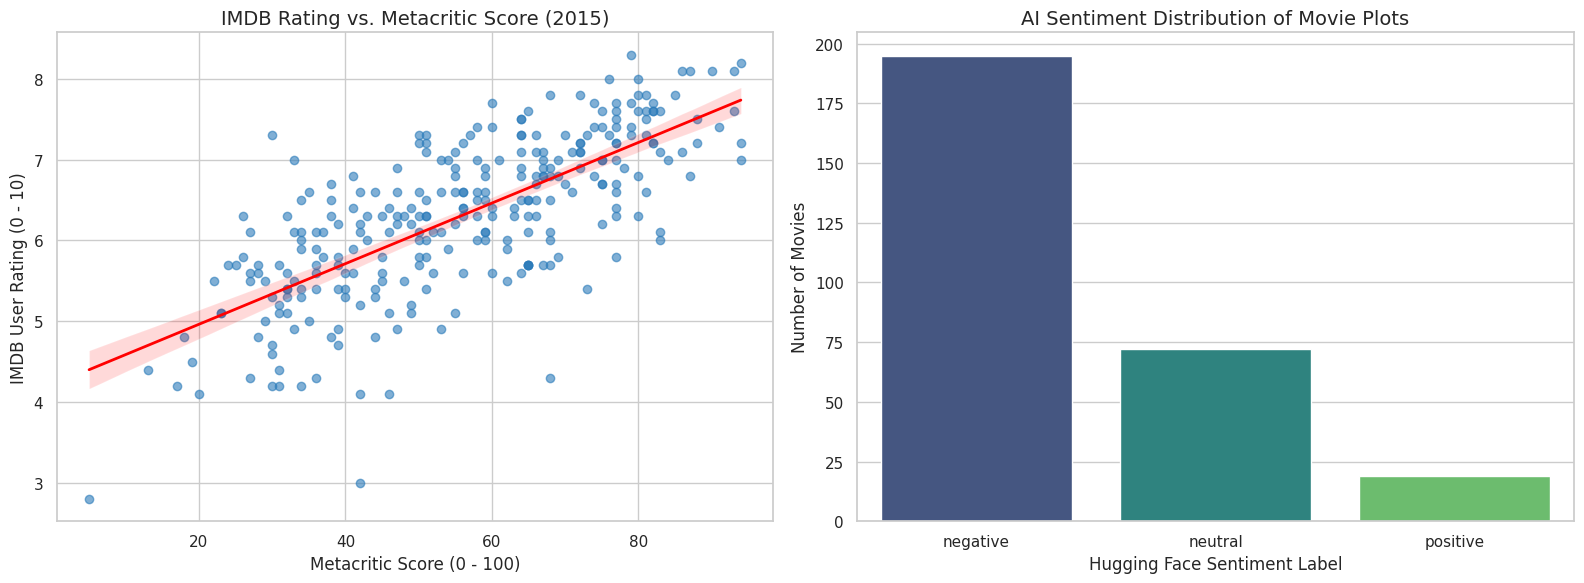

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CHART 1: OLS Regression (Metacritic vs IMDB)
# A scatter plot with a line of best fit to visualize the OLS results
sns.regplot(
    x='score',
    y='user_rating',
    data=merged_df,
    ax=axes[0],
    scatter_kws={'alpha':0.6, 'color': '#2b7bba'},
    line_kws={'color':'red', 'linewidth': 2}
)
axes[0].set_title('IMDB Rating vs. Metacritic Score (2015)', fontsize=14)
axes[0].set_xlabel('Metacritic Score (0 - 100)', fontsize=12)
axes[0].set_ylabel('IMDB User Rating (0 - 10)', fontsize=12)

# CHART 2: Sentiment Analysis Distribution
# A bar chart showing how many movies fell into each sentiment category
sns.countplot(
    x='sentiment_analysis',
    data=merged_df,
    ax=axes[1],
    palette='viridis',
    order=merged_df['sentiment_analysis'].value_counts().index
)
axes[1].set_title('AI Sentiment Distribution of Movie Plots', fontsize=14)
axes[1].set_xlabel('Hugging Face Sentiment Label', fontsize=12)
axes[1].set_ylabel('Number of Movies', fontsize=12)

plt.tight_layout()
plt.show()